<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/Maria_HeartCycle_FILTEREDDATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**FILTERED ICG**


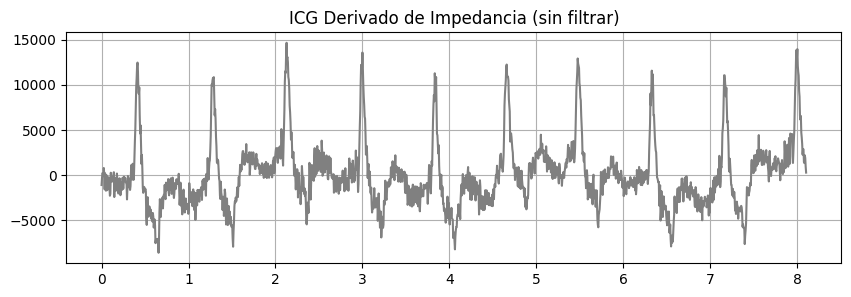

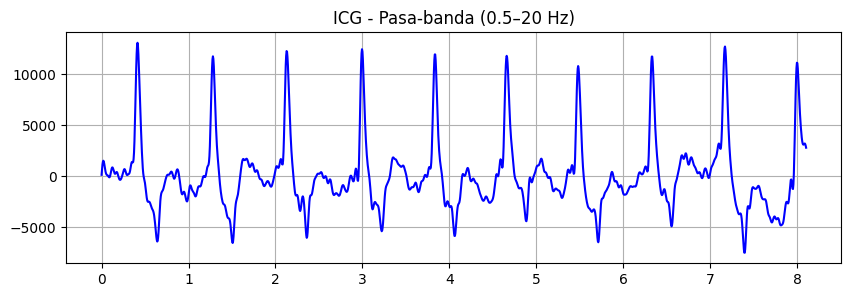

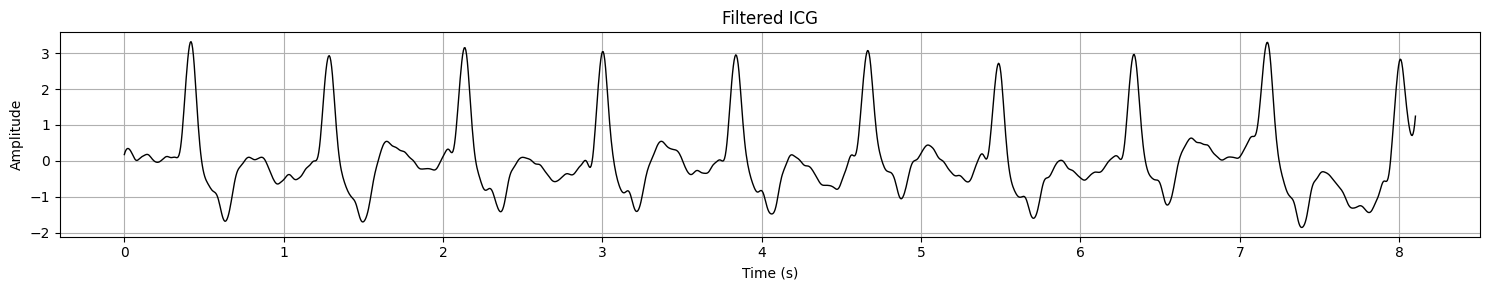

In [ ]:
from scipy.signal import butter, filtfilt, savgol_filter
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

# Cargar los datos
filename = f'/content/59146237_s0000008.mat'
data_raw_HC = sio.loadmat(filename)
measures = data_raw_HC['measure']
impedance = measures[1, 1]
impedance_data = impedance['data'][0, 0]
fs = 198.46762  # Frecuencia de muestreo

# Derivar la impedancia para obtener el ICG
icg_raw = np.gradient(impedance_data.flatten())

# Filtro pasa-banda Butterworth
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, data)

icg_bandpassed = butter_bandpass_filter(icg_raw, 0.5, 20, fs)

# Suavizado con filtro Savitzky-Golay
icg_filtered = savgol_filter(icg_bandpassed, window_length=25, polyorder=3)

#Normalización
icg_filtered = (icg_filtered - np.mean(icg_filtered)) / np.std(icg_filtered)

# Tiempo para graficar
tiempo = np.linspace(0, len(icg_filtered) / fs, len(icg_filtered))

# Plots
plt.figure(figsize=(10, 3))
#plt.subplot(3, 1, 1)
plt.plot(tiempo, icg_raw, label='ICG sin filtrar', color='gray')
plt.title('ICG Derivado de Impedancia (sin filtrar)')
plt.grid(True)

#plt.subplot(3, 1, 2)
plt.figure(figsize=(10, 3))
plt.plot(tiempo, icg_bandpassed, label='ICG con filtro pasa-banda', color='blue')
plt.title('ICG - Pasa-banda (0.5–20 Hz)')
plt.grid(True)

#plt.subplot(3, 1, 3)
plt.figure(figsize=(15, 3))
plt.plot(tiempo, icg_filtered, label='ICG final filtrado (SG)', color='black', linewidth='1')
plt.title('Filtered ICG')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()


Now that we have the ICG signal filtered, we are going to hold on to it some calculated parameters that have been provided

We focus on plotting **PreEjection period**

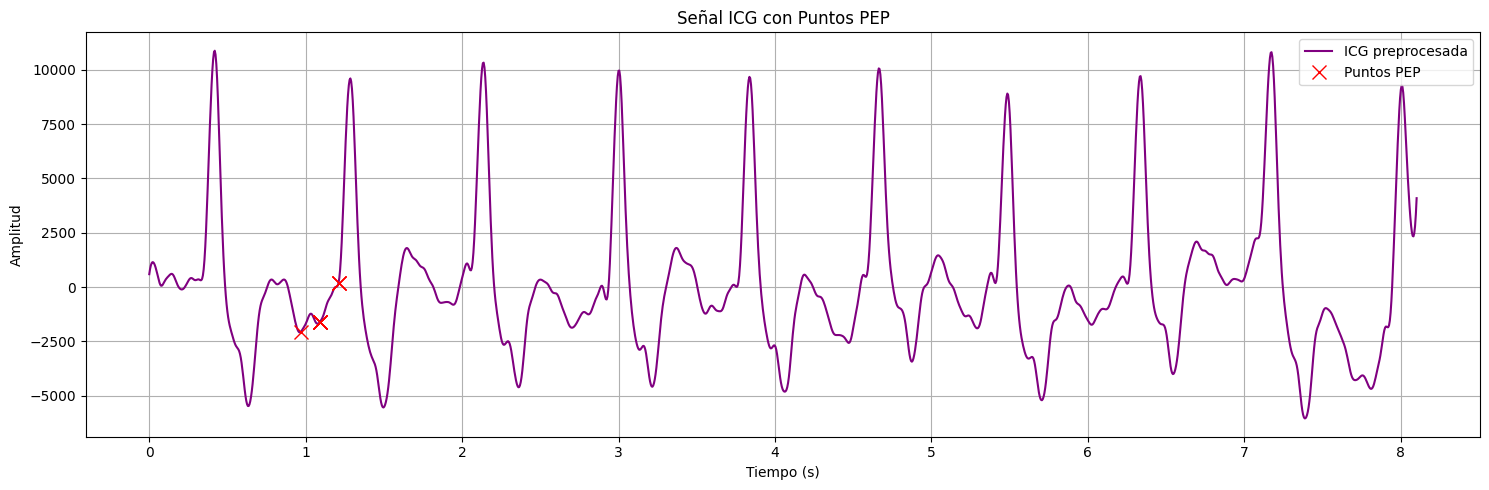

In [ ]:
# Extraer PEP
PEP = measures[4, 1]
PEP_time = PEP['time']
PEP_data = PEP['data']
PEP_data_value = PEP_data[0, 0]  # Valores de tiempo en segundos

# Convertir tiempo de PEP a índices de muestra
frecuencia_muestreo=200
PEP_sample_indices = (PEP_data_value.flatten() * frecuencia_muestreo).astype(int)

# Obtener amplitudes de la señal preprocesada en los puntos PEP
PEP_amplitudes = icg_filtered[PEP_sample_indices]

# Graficar señal preprocesada con los puntos PEP superpuestos
plt.figure(figsize=(15, 5))
plt.plot(tiempo, icg_filtered, label='ICG preprocesada', color='purple')
plt.plot(tiempo[PEP_sample_indices], PEP_amplitudes, 'rx', markersize=10, label='Puntos PEP')
plt.title('Señal ICG con Puntos PEP')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


*Esto no tiene mucho sentido plottearlo ya que es el cálculo de tiempo

We focus on plotting **Time of aortic valve opening**

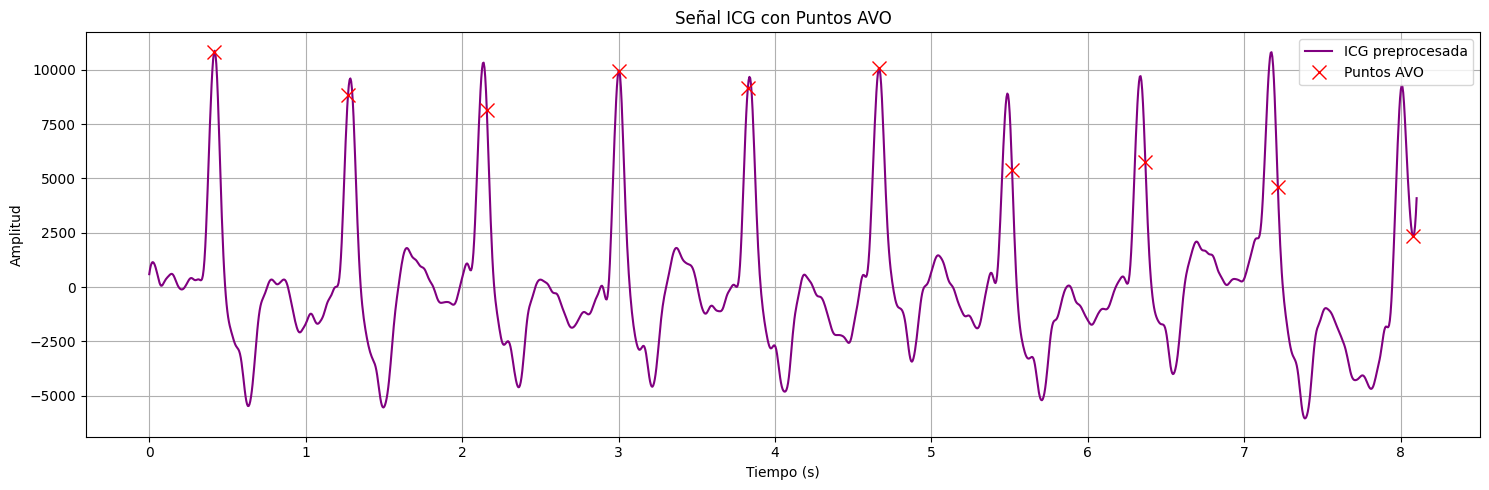

In [ ]:
# Extraer AVO
AVO = measures[3, 1]
AVO_time = AVO['time']
AVO_data = AVO['data']
AVO_data_value = AVO_data[0, 0]  # Valores de tiempo en segundos

# Convertir tiempo de AVO a índices de muestra
frecuencia_muestreo=200
AVO_sample_indices = (AVO_data_value.flatten() * frecuencia_muestreo).astype(int)
AVO_sample_indices = AVO_sample_indices[AVO_sample_indices < len(senal_sin_linea_base)]

# Obtener amplitudes de la señal preprocesada en los puntos PEP
AVO_amplitudes = icg_filtered[AVO_sample_indices]

# Graficar señal preprocesada con los puntos PEP superpuestos
plt.figure(figsize=(15, 5))
plt.plot(tiempo, icg_filtered, label='ICG preprocesada', color='purple')
plt.plot(tiempo[AVO_sample_indices], AVO_amplitudes, 'rx', markersize=10, label='Puntos AVO')
plt.title('Señal ICG con Puntos AVO')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Maybe it can appear on other patient but not on this one

We focus on plotting **Time of aortic valve closure**

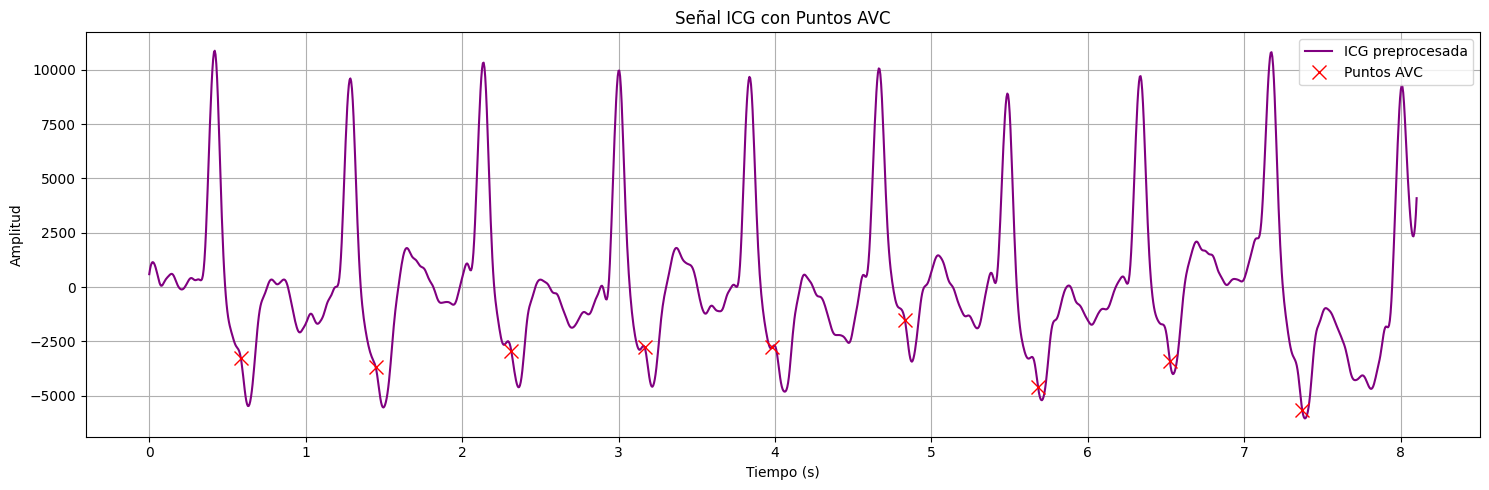

In [ ]:
AVC = measures[5, 1]
AVC_time = AVC['time']
AVC_data = AVC['data']
AVC_data_value = AVC_data[0, 0]  # Valores de tiempo en segundos

# Convertir tiempo de AVO a índices de muestra
frecuencia_muestreo=200
AVC_sample_indices = (AVC_data_value.flatten() * frecuencia_muestreo).astype(int)
AVC_sample_indices = AVC_sample_indices[AVC_sample_indices < len(icg_filtered)]

# Obtener amplitudes de la señal preprocesada en los puntos PEP
AVC_amplitudes = icg_filtered[AVC_sample_indices]

# Graficar señal preprocesada con los puntos PEP superpuestos
plt.figure(figsize=(15, 5))
plt.plot(tiempo, icg_filtered, label='ICG preprocesada', color='purple')
plt.plot(tiempo[AVC_sample_indices], AVC_amplitudes, 'rx', markersize=10, label='Puntos AVC')
plt.title('Señal ICG con Puntos AVC')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

We focus on plotting **Left Ventricle Ejection Time**

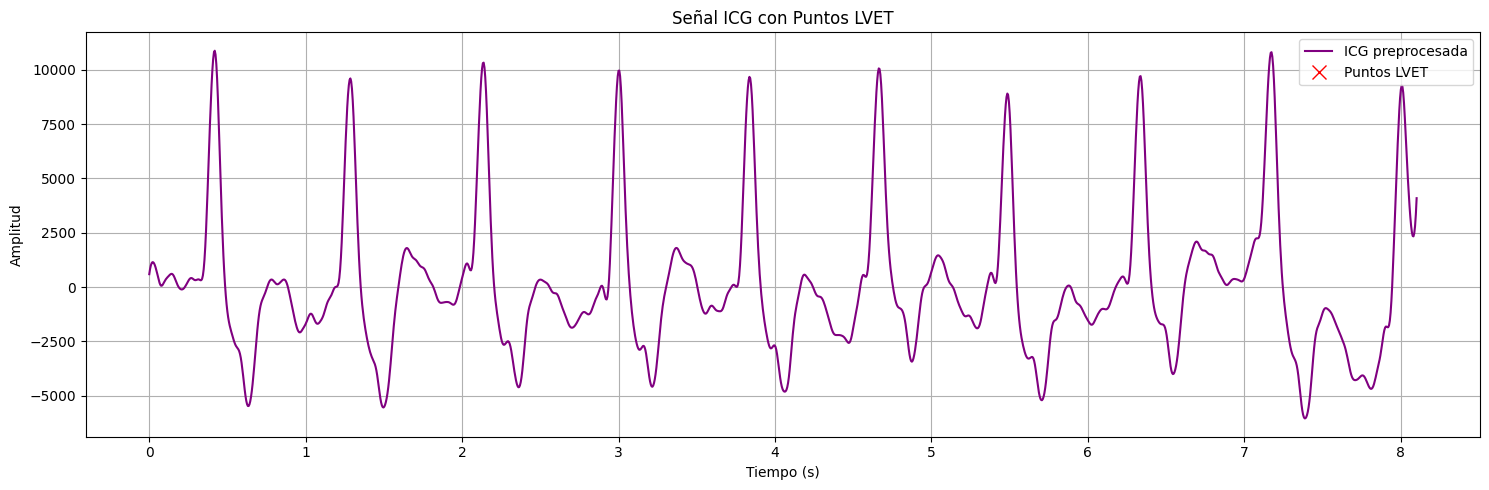

In [ ]:
# Extraer LVET
LVET = measures[6, 1]
LVET_time = LVET['time']
LVET_data = LVET['data']
LVET_data_value = LVET_data[0, 0]  # Valores de tiempo en segundos

# Convertir tiempo de PEP a índices de muestra
frecuencia_muestreo=200
LVET_sample_indices = (LVET_data_value.flatten() * frecuencia_muestreo).astype(int)
LVET_sample_indices = LVET_sample_indices[LVET_sample_indices < len(senal_sin_linea_base)]

# Obtener amplitudes de la señal preprocesada en los puntos PEP
LVET_amplitudes = icg_filtered[LVET_sample_indices]

# Graficar señal preprocesada con los puntos PEP superpuestos
plt.figure(figsize=(15, 5))
plt.plot(tiempo, icg_filtered, label='ICG preprocesada', color='purple')
plt.plot(tiempo[LVET_sample_indices], LVET_amplitudes, 'rx', markersize=10, label='Puntos LVET')
plt.title('Señal ICG con Puntos LVET')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()